<a href="https://colab.research.google.com/github/iris-hep/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_2_1_visualize_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## ============================================================================
# Google Colab setup — run me first.  Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/iris-hep/nsbi-lhc-toolkit.git"  # package + tutorial helpers
BRANCH   = "ml4hep_school_tutorial"
N_BKG, N_SIG = 1_000_000, 1_000_000     # Colab-sized dataset (raise for less MC noise in the fit)
USE_DRIVE = False                    # True -> save data/models to Google Drive so they
                                    # persist across notebooks & sessions (see notes above)
# ----------------------------------------------------------------------------

import subprocess
from pathlib import Path

DEPENDENCIES = [
    "pytorch-lightning",
    "onnx",
    "onnxruntime",
    "onnxscript",
    "iminuit",
    "mplhep",
]


def run(*args, env=None):
    """Run one setup command and stop immediately if it fails."""
    subprocess.run([str(arg) for arg in args], check=True, env=env)


IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab")
    else:
        ROOT = Path("/content")
    ROOT.mkdir(parents=True, exist_ok=True)

    # Keep the checkout where earlier notebook versions placed it. The source
    # helpers now live in ml4hep_tifr_colab, while the untracked legacy
    # ml4hep_tifr directory remains the persistent workspace for data/models.
    REPO_DIR = ROOT / "nsbi-lhc-toolkit"
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    WORK_DIR = REPO_DIR / "workshops" / "ml4hep_tifr"

    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
    else:
        run("git", "-C", REPO_DIR, "remote", "set-url", "origin", REPO_URL)
        run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)
        run("git", "-C", REPO_DIR, "checkout", BRANCH)
        run("git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH)

    run(
        "git", "-C", REPO_DIR, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )

    # Import package code and tutorial-local helpers from their new locations.
    for import_dir in (REPO_DIR / "src", TUTORIAL_DIR):
        import_path = str(import_dir.resolve())
        if import_path not in sys.path:
            sys.path.insert(0, import_path)

    run(sys.executable, "-m", "pip", "install", "-q", *DEPENDENCIES)

    # Preserve the exact old working location. Existing dataframes, models,
    # densities, and plots are reused; only a missing directory is created.
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)

    remake_events = globals().get("REMAKE_EVENTS", False)
    if remake_events or not Path("dataframes/signal.parquet").exists():
        run(
            sys.executable,
            TUTORIAL_DIR / "generate_distributions.py",
            "--n_bkg", N_BKG,
            "--n_sig", N_SIG,
        )

print("Working dir:", os.getcwd())


Working dir: /Users/jaysandesara/Documents/NSBI-workflow-tutorial/workshops/ml4hep_tifr_colab


In [ ]:
import pandas as pd
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
hep.style.use("ATLAS")

In [ ]:
BASE_PATH = "./dataframes/"

In [ ]:
signal = pd.read_parquet(f"{BASE_PATH}/signal.parquet")
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

### Visualising the dataset

Before training the NN, lets take a look at what the "kinematics" of the final state look like.

Note how some variables are more discriminating than others, and how several of them are **multi-modal** (more than one bump). Our goal with SBI is to use all of the variables — including their high-dimensional correlations — to build the model.


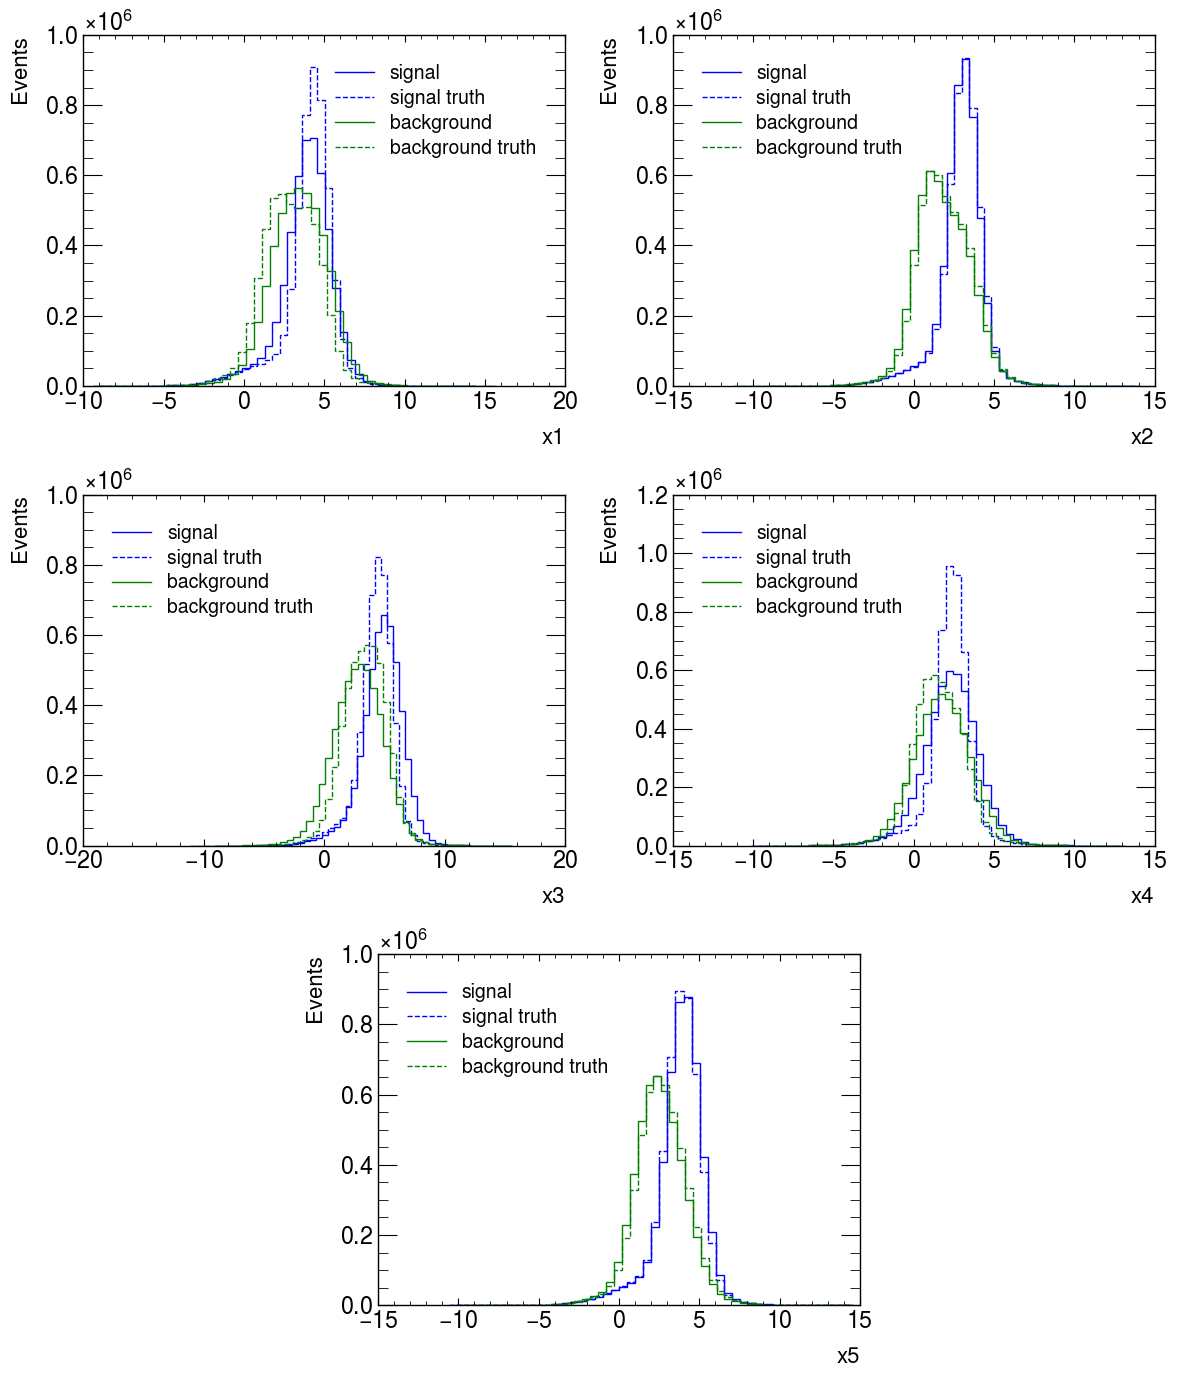

In [ ]:
variables = ["x1", "x2", "x3", "x4", "x5"]
truth = ["z1", "z2", "z3", "z4", "z5"]

mosaic = [
    ["x1", "x1", "x2", "x2"],
    ["x3", "x3", "x4", "x4"],
    [".",  "x5", "x5", "."],
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(12, 14))

for var,tr in zip(variables,truth):
    ax = axes[var]

    x_sig = np.array(signal[var])
    x_sig_tr = np.array(signal[tr])
    h_sig, bins = np.histogram(x_sig, bins=50)
    h_sig_tr, bins = np.histogram(x_sig_tr, bins=50)
    hep.histplot(h_sig, bins, ax=ax, label="signal", color='blue', linewidth=1.0)
    hep.histplot(h_sig_tr, bins, ax=ax, label="signal truth", ls='--', color='blue', linewidth=1.0)

    x_bkg = np.array(background[var])
    x_bkg_tr = np.array(background[tr])
    h_bkg, bins = np.histogram(x_bkg, bins=50)
    h_bkg_tr, bins = np.histogram(x_bkg_tr, bins=50)
    hep.histplot(h_bkg, bins, ax=ax, label="background", linewidth=1.0, color="green")
    hep.histplot(h_bkg_tr, bins, ax=ax, label="background truth", ls='--', linewidth=1.0, color="green")

    ax.legend(fontsize=14)
    ax.set_xlabel(var, size=16)
    ax.set_ylabel("Events", size=16)

fig.tight_layout()